# Weekly ML Signal Framework — Audited V1 Baseline
### *by Dr. W. Vera-Tudela*

## 1. Introduction & Objective

This is a custom backtesting framework built from scratch in Jupyter Notebook with supporting functions in a separate Python file. The framework uses machine learning and walk-forward validation to predict the price trend in the next 5 days as a trading strategy to either buy, hold, or sell. It uses three different ML models, compares them agains a simple MA signal generator (Q1).  



## 2. Data Pipeline

The structure of the data flow is as follows:

The pipeline:

1. Data Download
   
2. Feature Engineering
       
3. Target Variable
   - 5-day forward return, binarized, non-overlapping
     
4. Walk-Forward Validation

5. Model Training

6. Signal Generation on test window

7. Signal Evaluation Metrics

8. Backtesting
  
9. Feature Importance

10. Volume Hypothesis Test — does volume add predictive power beyond price alone?

11. Visualisation

In [1]:
# ==========================================================
# IMPORTS
# ==========================================================

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from lightgbm import LGBMClassifier

from sklearn.metrics import (accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score)


# ==========================================================
# PROJECT PATHS
# ==========================================================

PROJECT_DIR = Path.cwd().resolve()

REPO_DIR = (
    PROJECT_DIR
    if (PROJECT_DIR / "utils" / "ml_trading.py").exists()
    else PROJECT_DIR.parent
)

UTILS_DIR = REPO_DIR / "utils"

if not (UTILS_DIR / "ml_trading.py").exists():
    raise FileNotFoundError("Could not locate utils/ml_trading.py")

if str(UTILS_DIR) not in sys.path:
    sys.path.insert(0,
        str(UTILS_DIR)
    )


# ==========================================================
# CUSTOM FUNCTIONS
# ==========================================================

from ml_trading import (select_feature_families, reshape_market_data, build_feature_factory, walk_forward_predict, build_weekly_supervised_dataset, predictions_to_position, performance_summary, generate_uniform_random_decisions, run_random_benchmark_simulations,
                         backtest_weekly_position, generate_markov_random_decisions, summarize_random_results, median_random_row, model_factory)

print("Weekly ML Signal Framework — Audited V1 Baseline")

Weekly ML Signal Framework — Audited V1 Baseline


In [2]:
print("Current directory:")
print(Path.cwd())

print("\nUtilities directory:")
print(UTILS_DIR)

print("\nUtilities directory exists:")
print(UTILS_DIR.exists())

Current directory:
/Users/walt/Documents/GitHub/quant-research/Q5_ml_signal_generation

Utilities directory:
/Users/walt/Documents/GitHub/quant-research/utils

Utilities directory exists:
True


In [3]:
# ==========================================================
# LOAD DATA
# ==========================================================

starting_capital = 100_000
LOOKBACK = 25
BUY_THRESHOLD = 0.03
SELL_THRESHOLD = -0.02
TRANSACTION_COST = 0.001
PERIODS_PER_YEAR = 52
N_RANDOM_SIMULATIONS = 1_000
RANDOM_SEED = 42

lookback_years = 10

ticker = "AAPL"

end = (pd.Timestamp.today(tz="UTC").normalize())

start = end - pd.DateOffset(years=lookback_years)

ohlcv = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)

# Flatten yfinance MultiIndex if necessary
if isinstance(ohlcv.columns, pd.MultiIndex):
    ohlcv.columns = ohlcv.columns.get_level_values(0)

ohlcv = (ohlcv.reset_index())


## 3. Feature engineering

In [4]:
# ==========================================================
# CELL 3 — WEEKLY SUPERVISED DATASET
# ==========================================================

# ----------------------------------------------------------
# Create daily feature source
#
# The target generated here is irrelevant. We only need the
# daily lag structure and feature factory output.
# ----------------------------------------------------------

daily_supervised = reshape_market_data(
    df=ohlcv,
    lookback=LOOKBACK,
    prediction_horizon=1,
    classification_threshold=0.0,
)

featured_daily, feature_families = (
    build_feature_factory(
        daily_supervised
    )
)


# ----------------------------------------------------------
# Select V1 feature families
#
# Returns + distribution was the strongest controlled
# experiment in the earlier version.
# ----------------------------------------------------------

selected_families = [
    "base_returns",
    "distribution",
]

model_features = []

for family_name in selected_families:
    model_features.extend(
        feature_families[family_name]
    )

model_features = list(
    dict.fromkeys(model_features)
)


# ----------------------------------------------------------
# Build weekly open-to-next-open supervised observations
# ----------------------------------------------------------

weekly_data = build_weekly_supervised_dataset(
    ohlcv=ohlcv,
    featured_daily=featured_daily,
    feature_columns=model_features,
    buy_threshold=BUY_THRESHOLD,
    sell_threshold=SELL_THRESHOLD,
)


# ----------------------------------------------------------
# Inspection
# ----------------------------------------------------------

print("=" * 70)
print("WEEKLY DATASET CONFIGURATION")
print("=" * 70)

print(f"Ticker:              {ticker}")
print(f"Daily lookback:      {LOOKBACK} sessions")
print(f"Buy threshold:       {BUY_THRESHOLD:.2%}")
print(f"Sell threshold:      {SELL_THRESHOLD:.2%}")
print(f"Transaction cost:    {TRANSACTION_COST:.2%} per side")
print(f"Feature families:    {selected_families}")
print(f"Model features:      {len(model_features)}")

print("\nWeekly observations:")
print(f"Rows:                {len(weekly_data)}")

print(
    f"Decision-date range: "
    f"{weekly_data['decision_date'].min().date()} "
    f"→ "
    f"{weekly_data['decision_date'].max().date()}"
)

print("\nTarget counts:")
print(
    weekly_data["target"]
    .value_counts()
    .sort_index()
)

print("\nTarget proportions:")
print(
    weekly_data["target"]
    .value_counts(normalize=True)
    .sort_index()
)

print("\nFuture weekly return statistics:")
display(
    weekly_data["future_week_return"]
    .describe()
    .to_frame("future_week_return")
)

print("\nAlignment preview:")
display(
    weekly_data[
        [
            "feature_date",
            "decision_date",
            "entry_open",
            "next_decision_date",
            "next_entry_open",
            "future_week_return",
            "target",
        ]
    ].head(15)
)

WEEKLY DATASET CONFIGURATION
Ticker:              AAPL
Daily lookback:      25 sessions
Buy threshold:       3.00%
Sell threshold:      -2.00%
Transaction cost:    0.10% per side
Feature families:    ['base_returns', 'distribution']
Model features:      41

Weekly observations:
Rows:                515
Decision-date range: 2016-08-29 → 2026-07-06

Target counts:
target
-1    111
 0    289
 1    115
Name: count, dtype: int64

Target proportions:
target
-1    0.215534
 0    0.561165
 1    0.223301
Name: proportion, dtype: float64

Future weekly return statistics:


,future_week_return
count,515.000000
mean,0.005788
std,0.040040
min,-0.183448
25%,-0.016384
50%,0.006398
75%,0.026233
max,0.193228



Alignment preview:


Price,feature_date,decision_date,entry_open,next_decision_date,next_entry_open,future_week_return,target
0,2016-08-26,2016-08-29,24.403494,2016-09-06,24.696460,0.012005,0
1,2016-09-02,2016-09-06,24.696460,2016-09-12,23.494828,-0.048656,-1
2,2016-09-09,2016-09-12,23.494828,2016-09-19,26.365017,0.122163,1
3,2016-09-16,2016-09-19,26.365017,2016-09-26,25.552486,-0.030819,-1
4,2016-09-23,2016-09-26,25.552486,2016-10-03,25.797387,0.009584,0
5,2016-09-30,2016-10-03,25.797387,2016-10-10,26.326108,0.020495,0
6,2016-10-07,2016-10-10,26.326108,2016-10-17,26.854829,0.020084,0
7,2016-10-14,2016-10-17,26.854829,2016-10-24,26.802186,-0.001960,0
8,2016-10-21,2016-10-24,26.802186,2016-10-31,26.012539,-0.029462,-1
9,2016-10-28,2016-10-31,26.012539,2016-11-07,25.324788,-0.026439,-1


In [5]:
# ==========================================================
# WEEKLY RETURN THRESHOLD DIAGNOSTICS
# ==========================================================

weekly_returns = (
    weekly_data["future_week_return"]
    .dropna()
)

positive_returns = weekly_returns[
    weekly_returns > 0
]

negative_returns = weekly_returns[
    weekly_returns < 0
]

threshold_diagnostics = pd.DataFrame({
    "all_returns": weekly_returns.describe(),
    "positive_returns": positive_returns.describe(),
    "negative_returns": negative_returns.describe(),
})

print("=" * 70)
print("WEEKLY RETURN DISTRIBUTION")
print("=" * 70)

display(threshold_diagnostics)


summary = pd.DataFrame({
    "group": [
        "Positive weeks",
        "Negative weeks",
    ],
    "count": [
        len(positive_returns),
        len(negative_returns),
    ],
    "mean": [
        positive_returns.mean(),
        negative_returns.mean(),
    ],
    "median": [
        positive_returns.median(),
        negative_returns.median(),
    ],
    "q25": [
        positive_returns.quantile(0.25),
        negative_returns.quantile(0.25),
    ],
    "q75": [
        positive_returns.quantile(0.75),
        negative_returns.quantile(0.75),
    ],
})

display(
    summary.style.format({
        "mean": "{:.2%}",
        "median": "{:.2%}",
        "q25": "{:.2%}",
        "q75": "{:.2%}",
    })
)


print("\nCurrent thresholds")
print(f"Buy:     > {BUY_THRESHOLD:.2%}")
print(f"Sell:    < {SELL_THRESHOLD:.2%}")
print("Neutral: otherwise")

print("\nClass proportions under current thresholds:")

current_classes = np.select(
    [
        weekly_returns < SELL_THRESHOLD,
        weekly_returns > BUY_THRESHOLD,
    ],
    [
        -1,
        1,
    ],
    default=0,
)

print(
    pd.Series(current_classes)
    .value_counts(normalize=True)
    .sort_index()
)

WEEKLY RETURN DISTRIBUTION


,all_returns,positive_returns,negative_returns
count,515.000000,299.000000,216.000000
mean,0.005788,0.030608,-0.028569
std,0.040040,0.027974,0.026564
min,-0.183448,0.000089,-0.183448
25%,-0.016384,0.011159,-0.040405
50%,0.006398,0.023619,-0.021107
75%,0.026233,0.041515,-0.009450
max,0.193228,0.193228,-0.000339


,group,count,mean,median,q25,q75
0,Positive weeks,299,3.06%,2.36%,1.12%,4.15%
1,Negative weeks,216,-2.86%,-2.11%,-4.04%,-0.95%



Current thresholds
Buy:     > 3.00%
Sell:    < -2.00%
Neutral: otherwise

Class proportions under current thresholds:
-1    0.215534
 0    0.561165
 1    0.223301
Name: proportion, dtype: float64


## 4. Model training

In [6]:
# ==========================================================
# CELL 4 — FEATURE SELECTION + WALK-FORWARD MODEL
# ==========================================================

selected_families = [
    "base_returns",
    "distribution",
]

model_features = []

for family_name in selected_families:
    model_features.extend(
        feature_families[family_name]
    )

model_features = list(
    dict.fromkeys(model_features)
)


missing_model_features = [
    column
    for column in model_features
    if column not in weekly_data.columns
]

if missing_model_features:
    raise KeyError(
        "The following selected features are missing from "
        f"df_sampled:\n{missing_model_features}"
    )


print("Selected feature families:")

for family_name in selected_families:
    print(
        f"{family_name:<15}: "
        f"{len(feature_families[family_name])} features"
    )

print(f"\nTotal model features: {len(model_features)}")





predictions, fold_metrics = walk_forward_predict(
    data=weekly_data,
    feature_columns=model_features,
    target_column="target",
    date_column="decision_date",
    model_factory=model_factory,
    initial_train_size=0.50,
    validation_size=0.10,
    purge_rows=1,
    include_remainder_in_last_fold=True,
    minimum_validation_rows=None,
)

print("\nWalk-forward model completed.")
print(f"Out-of-sample predictions: {len(predictions)}")
print(f"Validation folds: {len(fold_metrics)}")

Selected feature families:
base_returns   : 25 features
distribution   : 16 features

Total model features: 41

Walk-forward model completed.
Out-of-sample predictions: 258
Validation folds: 5


## 5. Compute metrics

In [7]:
# ==========================================================
# CELL 5 — MODEL EVALUATION
# ==========================================================

# ----------------------------------------------------------
# Fold-level metrics
# ----------------------------------------------------------

print("=" * 70)
print("FOLD METRICS")
print("=" * 70)

display(
    fold_metrics[
        [
            "fold",
            "train_start",
            "train_end",
            "validation_start",
            "validation_end",
            "train_rows",
            "validation_rows",
            "purge_rows",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
        ]
    ]
)


# ----------------------------------------------------------
# Aggregate metrics
#
# We calculate both:
# 1. Mean fold metrics: every fold gets equal weight.
# 2. Pooled metrics: every prediction gets equal weight.
#
# The pooled metrics are more representative here because the
# final fold contains only a few observations.
# ----------------------------------------------------------

mean_fold_metrics = (
    fold_metrics[
        [
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
        ]
    ]
    .mean()
)

pooled_accuracy = accuracy_score(
    predictions["actual"],
    predictions["prediction"],
)

pooled_balanced_accuracy = balanced_accuracy_score(
    predictions["actual"],
    predictions["prediction"],
)

pooled_macro_f1 = f1_score(
    predictions["actual"],
    predictions["prediction"],
    average="macro",
)

summary_metrics = pd.DataFrame(
    {
        "mean_fold_metric": [
            mean_fold_metrics["accuracy"],
            mean_fold_metrics["balanced_accuracy"],
            mean_fold_metrics["macro_f1"],
        ],
        "pooled_oos_metric": [
            pooled_accuracy,
            pooled_balanced_accuracy,
            pooled_macro_f1,
        ],
    },
    index=[
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
    ],
)

print("\n" + "=" * 70)
print("SUMMARY METRICS")
print("=" * 70)

display(summary_metrics)


# ----------------------------------------------------------
# Class distributions
# ----------------------------------------------------------

class_distribution = pd.DataFrame({
    "actual": (
        predictions["actual"]
        .value_counts(normalize=True)
        .sort_index()
    ),
    "prediction": (
        predictions["prediction"]
        .value_counts(normalize=True)
        .sort_index()
    ),
}).fillna(0)

class_distribution.index.name = "class"

print("\n" + "=" * 70)
print("CLASS DISTRIBUTION")
print("=" * 70)

display(class_distribution)


# ----------------------------------------------------------
# Confusion matrix
# ----------------------------------------------------------

confusion = pd.DataFrame(
    confusion_matrix(
        predictions["actual"],
        predictions["prediction"],
        labels=[-1, 0, 1],
    ),
    index=[
        "Actual -1",
        "Actual 0",
        "Actual 1",
    ],
    columns=[
        "Predicted -1",
        "Predicted 0",
        "Predicted 1",
    ],
)

print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

display(confusion)


# ----------------------------------------------------------
# Per-class report
# ----------------------------------------------------------

classification = pd.DataFrame(
    classification_report(
        predictions["actual"],
        predictions["prediction"],
        labels=[-1, 0, 1],
        target_names=[
            "Down <-2%",
            "Neutral",
            "Up >2%",
        ],
        output_dict=True,
        zero_division=0,
    )
).T

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

display(classification)


# ----------------------------------------------------------
# Prediction preview
# ----------------------------------------------------------

print("\n" + "=" * 70)
print("DATED OUT-OF-SAMPLE PREDICTIONS")
print("=" * 70)

display(
    predictions.head(10)
)

FOLD METRICS


,fold,train_start,train_end,validation_start,validation_end,train_rows,validation_rows,purge_rows,accuracy,balanced_accuracy,macro_f1
0,1,2016-08-29,2021-07-19,2021-08-02,2022-07-18,256,51,1,0.392157,0.297585,0.222222
1,2,2016-08-29,2022-07-11,2022-07-25,2023-07-10,307,51,1,0.529412,0.379121,0.328571
2,3,2016-08-29,2023-07-03,2023-07-17,2024-07-01,358,51,1,0.529412,0.310345,0.230769
3,4,2016-08-29,2024-06-24,2024-07-08,2025-06-23,409,51,1,0.470588,0.307692,0.222222
4,5,2016-08-29,2025-06-16,2025-06-30,2026-07-06,460,54,1,0.574074,0.333333,0.252033



SUMMARY METRICS


,mean_fold_metric,pooled_oos_metric
accuracy,0.499129,0.500000
balanced_accuracy,0.325615,0.330799
macro_f1,0.251164,0.263568



CLASS DISTRIBUTION


...

,Predicted -1,Predicted 0,Predicted 1
Actual -1,1,58,5
Actual 0,7,125,3
Actual 1,6,50,3



CLASSIFICATION REPORT


,precision,recall,f1-score,support
Down <-2%,0.071429,0.015625,0.025641,64.0
Neutral,0.536481,0.925926,0.679348,135.0
Up >2%,0.272727,0.050847,0.085714,59.0
accuracy,0.500000,0.500000,0.500000,0.5
macro avg,0.293546,0.330799,0.263568,258.0
weighted avg,0.360803,0.500000,0.381435,258.0



DATED OUT-OF-SAMPLE PREDICTIONS


,decision_date,fold,actual,prediction,prob_-1,prob_0,prob_1
0,2021-08-02,1,0,0,0.201784,0.664840,0.133377
1,2021-08-09,1,0,0,0.184353,0.658397,0.157250
2,2021-08-16,1,0,0,0.109092,0.598842,0.292066
3,2021-08-23,1,0,0,0.087841,0.860865,0.051294
4,2021-08-30,1,1,0,0.108853,0.741369,0.149778
5,2021-09-07,1,-1,0,0.138169,0.748699,0.113131
6,2021-09-13,1,-1,0,0.079818,0.817041,0.103140
7,2021-09-20,1,0,0,0.335487,0.443486,0.221027
8,2021-09-27,1,-1,0,0.143263,0.674131,0.182606
9,2021-10-04,1,0,0,0.307932,0.622053,0.070015


## 6. Feature importance

FULL-SAMPLE MODEL FEATURE IMPORTANCE — DESCRIPTIVE ONLY
Note: this is in-sample split importance, not out-of-sample causal importance.


,rank,feature,importance,importance_pct,cumulative_pct
0,1,ret_25,126,5.252188,5.252188
1,2,ret_24,107,4.460192,9.712380
2,3,ret_iqr,99,4.126719,13.839100
3,4,ret_9,95,3.959983,17.799083
4,5,ret_2,94,3.918299,21.717382
5,6,ret_21,88,3.668195,25.385577
6,7,ret_3,86,3.584827,28.970404
7,8,ret_17,81,3.376407,32.346811
8,9,ret_19,80,3.334723,35.681534
9,10,ret_7,77,3.209671,38.891205


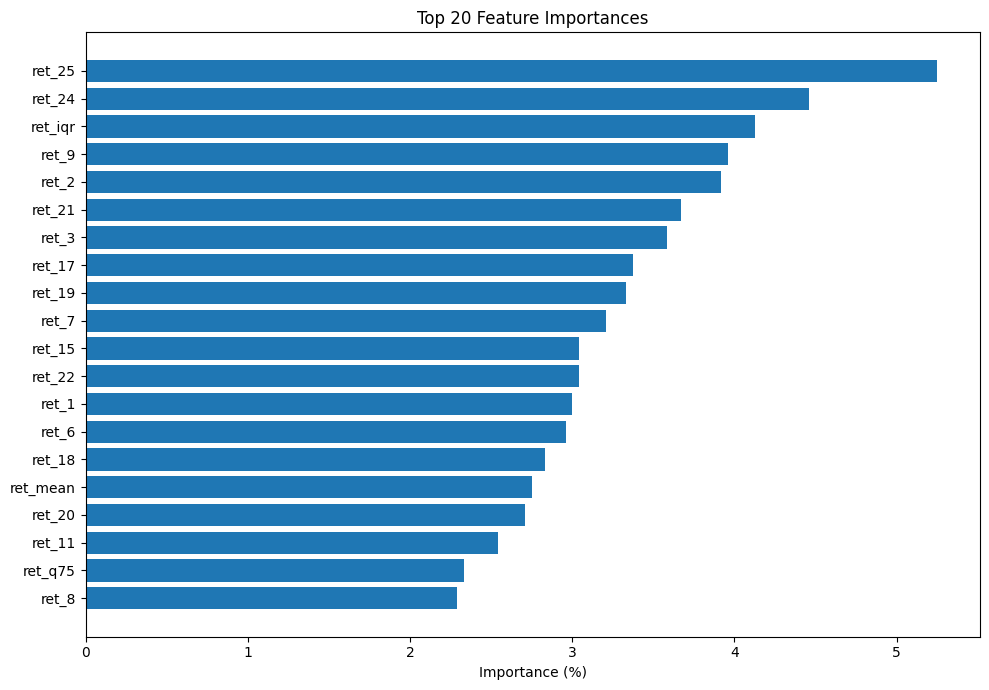

In [8]:
# ==========================================================
# CELL 6 — FEATURE IMPORTANCE
# ==========================================================

importance_model = model_factory()

importance_model.fit(
    weekly_data[model_features],
    weekly_data["target"],
)

importance = (
    pd.DataFrame({
        "feature": model_features,
        "importance": importance_model.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

importance["importance_pct"] = (
    100
    * importance["importance"]
    / importance["importance"].sum()
)

importance["cumulative_pct"] = (
    importance["importance_pct"].cumsum()
)

importance.insert(
    0,
    "rank",
    np.arange(1, len(importance) + 1)
)

print("=" * 70)
print("FULL-SAMPLE MODEL FEATURE IMPORTANCE — DESCRIPTIVE ONLY")
print("=" * 70)
print("Note: this is in-sample split importance, not out-of-sample causal importance.")

display(importance.head(20))

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

top_n = 20

plt.figure(figsize=(10, 7))

plt.barh(importance.loc[:top_n-1, "feature"][::-1], importance.loc[:top_n-1, "importance_pct"][::-1])

plt.xlabel("Importance (%)")
plt.title(f"Top {top_n} Feature Importances")
plt.tight_layout()
plt.show()

## 7. Signal backtesting

In [9]:
# ==========================================================
# CELL 7 — ALIGNED WEEKLY TRADING SIGNALS
# ==========================================================
decision_dates = pd.DatetimeIndex(predictions["decision_date"].sort_values().drop_duplicates())
oos_weekly = weekly_data.set_index("decision_date").sort_index().reindex(decision_dates)
if oos_weekly["future_week_return"].isna().any():
    raise ValueError("Missing weekly returns on prediction decision dates.")
weekly_returns = oos_weekly["future_week_return"].astype(float)

signal_ml_weekly = predictions.set_index("decision_date")["prediction"].sort_index().reindex(weekly_returns.index).astype(int)
position_ml_weekly = predictions_to_position(signal_ml_weekly, 0)
oracle_decisions = oos_weekly["target"].astype(int)
position_oracle_weekly = predictions_to_position(oracle_decisions, 0)
position_hodl_weekly = pd.Series(1, index=weekly_returns.index, dtype="int64", name="position")

# Daily closes are used only for the final completed pre-open MA state.
daily_close = ohlcv.set_index("Date")["Close"].sort_index()
ma_state = pd.DataFrame({
    "ma_date": daily_close.index,
    "MA_position": (daily_close.rolling(20).mean() > daily_close.rolling(50).mean()).astype(int).to_numpy(),
})
weekly_ma = pd.merge_asof(
    pd.DataFrame({"decision_date": weekly_returns.index}),
    ma_state.sort_values("ma_date"), left_on="decision_date", right_on="ma_date",
    direction="backward", allow_exact_matches=False,
)
if weekly_ma["MA_position"].isna().any():
    raise ValueError("Prior-session MA state missing for a decision date.")
position_q1_weekly = weekly_ma.set_index("decision_date")["MA_position"].reindex(weekly_returns.index).astype("int64").rename("position")

alignment_preview = pd.DataFrame({
    "feature_date": oos_weekly["feature_date"], "decision_date": weekly_returns.index,
    "next_decision_date": oos_weekly["next_decision_date"], "future_week_return": weekly_returns,
    "ML_decision": signal_ml_weekly, "ML_position": position_ml_weekly,
    "MA_position": position_q1_weekly, "HODL_position": position_hodl_weekly,
    "Oracle_decision": oracle_decisions, "Oracle_position": position_oracle_weekly,
})
print(f"Aligned weekly intervals: {len(weekly_returns)}")
display(alignment_preview.head(20))


Aligned weekly intervals: 258


,feature_date,decision_date,next_decision_date,future_week_return,ML_decision,ML_position,MA_position,HODL_position,Oracle_decision,Oracle_position
decision_date,,,,,,,,,,
2021-08-02,2021-07-30,2021-08-02,2021-08-09,0.000403,0,0,1,1,0,0
2021-08-09,2021-08-06,2021-08-09,2021-08-16,0.016005,0,0,1,1,0,0
2021-08-16,2021-08-13,2021-08-16,2021-08-23,-0.001548,0,0,1,1,0,0
2021-08-23,2021-08-20,2021-08-23,2021-08-30,0.004652,0,0,1,1,0,0
2021-08-30,2021-08-27,2021-08-30,2021-09-07,0.040067,0,0,1,1,1,1
2021-09-07,2021-09-03,2021-09-07,2021-09-13,-0.028005,0,0,1,1,-1,0
2021-09-13,2021-09-10,2021-09-13,2021-09-20,-0.045343,0,0,1,1,-1,0
2021-09-20,2021-09-17,2021-09-20,2021-09-27,0.011613,0,0,1,1,0,0
2021-09-27,2021-09-24,2021-09-27,2021-10-04,-0.025503,0,0,1,1,-1,0


## 8. Results visualization

In [10]:
# ==========================================================
# CELL 8 — UNIFIED WEEKLY STRATEGY BACKTESTS
# ==========================================================
bt_ml = backtest_weekly_position(weekly_returns, position_ml_weekly, starting_capital, TRANSACTION_COST)
bt_q1 = backtest_weekly_position(weekly_returns, position_q1_weekly, starting_capital, TRANSACTION_COST)
bt_hodl = backtest_weekly_position(weekly_returns, position_hodl_weekly, starting_capital, TRANSACTION_COST)
bt_oracle = backtest_weekly_position(weekly_returns, position_oracle_weekly, starting_capital, TRANSACTION_COST)

def strategy_summary(backtest, name):
    return performance_summary(backtest, name, starting_capital, PERIODS_PER_YEAR)

performance = pd.DataFrame([
    strategy_summary(bt_ml, "ML"), strategy_summary(bt_q1, "MA crossover"),
    strategy_summary(bt_hodl, "HODL"), strategy_summary(bt_oracle, "Oracle"),
]).set_index("strategy")
print("All strategies use identical weekly open-to-next-open returns and costs.")
print("total_cost is a cumulative modeled cost fraction, not cash currency.")
display(performance.style.format({
    "final_value": "${:,.0f}", "total_return": "{:.2%}", "CAGR": "{:.2%}",
    "annualized_volatility": "{:.2%}", "Sharpe": "{:.3f}", "max_drawdown": "{:.2%}",
    "exposure": "{:.2%}", "entries": "{:,.0f}", "trade_events": "{:,.0f}", "total_cost": "{:.2%}",
}))


All strategies use identical weekly open-to-next-open returns and costs.
total_cost is a cumulative modeled cost fraction, not cash currency.


,final_value,total_return,CAGR,annualized_volatility,Sharpe,max_drawdown,exposure,entries,trade_events,total_cost
strategy,,,,,,,,,,
ML,"$112,835",12.84%,2.48%,14.18%,0.243,-22.13%,32.95%,6,12,1.20%
MA crossover,"$158,843",58.84%,9.85%,19.87%,0.568,-25.53%,60.08%,15,29,2.90%
HODL,"$221,991",121.99%,17.58%,29.29%,0.696,-30.37%,100.00%,1,1,0.10%
Oracle,"$3,082,176",2982.18%,100.58%,19.00%,3.751,-3.04%,48.06%,33,65,6.50%


In [11]:
print("Weekly ML backtest identity check")
print("Start:", bt_ml.index.min(), "End:", bt_ml.index.max(), "Weekly rows:", len(bt_ml))
print("Final equity:", bt_ml["equity"].iloc[-1])
print("Exposure:", bt_ml["position"].mean())
print("Trade events:", (bt_ml["turnover"] > 0).sum())
print("Cumulative modeled cost fraction:", bt_ml["trading_cost"].sum())


Weekly ML backtest identity check
Start: 2021-08-02 00:00:00 End: 2026-07-06 00:00:00 Weekly rows: 258
Final equity: 112835.16159889402
Exposure: 0.32945736434108525
Trade events: 12
Cumulative modeled cost fraction: 0.012


## 9. Benchmarks

In [12]:
# ==========================================================
# CELL 9 — WEEKLY BENCHMARK CONFIGURATION
# ==========================================================
print("Benchmark configuration")
print("=" * 60)
print(f"Random simulations:    {N_RANDOM_SIMULATIONS:,}")
print(f"Trading cost per side: {TRANSACTION_COST:.2%}")
print(f"Weekly decision dates: {len(decision_dates)}")
print("\nWeekly target thresholds")
print(f"Buy  > {BUY_THRESHOLD:.1%}")
print(f"Sell < {SELL_THRESHOLD:.1%}")
print("Neutral otherwise")
print("\nOracle decision distribution:")
print(oracle_decisions.value_counts(normalize=True).sort_index())


Benchmark configuration
Random simulations:    1,000
Trading cost per side: 0.10%
Weekly decision dates: 258

Weekly target thresholds
Buy  > 3.0%
Sell < -2.0%
Neutral otherwise

Oracle decision distribution:
target
-1    0.248062
 0    0.523256
 1    0.228682
Name: proportion, dtype: float64


In [13]:
assert weekly_returns.index.equals(position_ml_weekly.index)
assert weekly_returns.index.equals(position_q1_weekly.index)
assert weekly_returns.index.equals(position_hodl_weekly.index)
assert weekly_returns.index.equals(position_oracle_weekly.index)
assert position_ml_weekly.isin([0, 1]).all()
assert position_q1_weekly.isin([0, 1]).all()
assert position_hodl_weekly.isin([0, 1]).all()
assert position_oracle_weekly.isin([0, 1]).all()
assert not weekly_returns.isna().any()
assert weekly_returns.index.is_unique
assert weekly_returns.index.is_monotonic_increasing
print("AUDITED WEEKLY BACKTEST")
print("-----------------------")
print("Decision interval: current weekly open to next weekly open")
print("Feature cutoff: final market observation before decision open")
print(f"Annualization: {PERIODS_PER_YEAR} weekly periods")
print(f"Transaction cost: {TRANSACTION_COST:.3%} per side")
print("Fractional positions: yes")
print("Purge rows: 1")
print(f"Random simulations: {N_RANDOM_SIMULATIONS:,}")


AUDITED WEEKLY BACKTEST
-----------------------
Decision interval: current weekly open to next weekly open
Feature cutoff: final market observation before decision open
Annualization: 52 weekly periods
Transaction cost: 0.100% per side
Fractional positions: yes
Purge rows: 1
Random simulations: 1,000


## 10. Random simulations and complete comparison

In [14]:
# ==========================================================
# CELL 10 — WEEKLY RANDOM BENCHMARK SIMULATIONS
# ==========================================================
rng_uniform = np.random.default_rng(RANDOM_SEED)
rng_markov = np.random.default_rng(RANDOM_SEED + 1)
uniform_random_results = run_random_benchmark_simulations(
    generate_uniform_random_decisions, rng_uniform, "Uniform random", N_RANDOM_SIMULATIONS,
    weekly_returns.index, weekly_returns, starting_capital, TRANSACTION_COST, PERIODS_PER_YEAR,
)
markov_random_results = run_random_benchmark_simulations(
    generate_markov_random_decisions, rng_markov, "Markov random", N_RANDOM_SIMULATIONS,
    weekly_returns.index, weekly_returns, starting_capital, TRANSACTION_COST, PERIODS_PER_YEAR,
)
uniform_random_summary = summarize_random_results(uniform_random_results, "Uniform random")
markov_random_summary = summarize_random_results(markov_random_results, "Markov random")
random_summary = pd.concat([uniform_random_summary, markov_random_summary], ignore_index=True)
print("=" * 70); print("RANDOM BENCHMARK DISTRIBUTIONS"); print("=" * 70)
display(random_summary)

random_median_rows = pd.DataFrame([
    median_random_row(uniform_random_results, "Uniform random median", starting_capital),
    median_random_row(markov_random_results, "Markov random median", starting_capital),
]).set_index("strategy")
deterministic_performance = pd.DataFrame([
    strategy_summary(bt_ml, "ML"), strategy_summary(bt_q1, "MA crossover"),
    strategy_summary(bt_hodl, "HODL"), strategy_summary(bt_oracle, "Oracle"),
]).set_index("strategy")
benchmark_performance = pd.concat([deterministic_performance, random_median_rows])
comparison_columns = ["final_value", "total_return", "CAGR", "annualized_volatility", "Sharpe", "max_drawdown", "exposure", "entries", "trade_events", "total_cost"]
print("\n" + "=" * 70); print("COMPLETE WEEKLY BENCHMARK COMPARISON"); print("=" * 70)
display(benchmark_performance[comparison_columns].style.format({
    "final_value": "${:,.0f}", "total_return": "{:.2%}", "CAGR": "{:.2%}",
    "annualized_volatility": "{:.2%}", "Sharpe": "{:.3f}", "max_drawdown": "{:.2%}",
    "exposure": "{:.2%}", "entries": "{:,.0f}", "trade_events": "{:,.0f}", "total_cost": "{:.2%}",
}))
ml_metrics = strategy_summary(bt_ml, "ML")
percentile_rows = []
for benchmark_name, results in [("Uniform random", uniform_random_results), ("Markov random", markov_random_results)]:
    for metric in ["CAGR", "Sharpe", "max_drawdown", "final_value"]:
        ml_value = ml_metrics[metric]
        # Larger is better; for drawdown, -0.20 is better than -0.50.
        percentile = results[metric].le(ml_value).mean()
        percentile_rows.append({"benchmark": benchmark_name, "metric": metric, "ML_value": ml_value, "ML_percentile": percentile})
ml_random_percentiles = pd.DataFrame(percentile_rows)
print("\n" + "=" * 70); print("ML PERCENTILE RANK VERSUS WEEKLY RANDOM STRATEGIES"); print("=" * 70)
display(ml_random_percentiles.style.format({"ML_value": "{:.4f}", "ML_percentile": "{:.2%}"}))


RANDOM BENCHMARK DISTRIBUTIONS


,benchmark,metric,p05,median,mean,p95
0,Uniform random,final_value,82140.436509,133059.321820,141871.677366,226036.610034
1,Uniform random,total_return,-0.178596,0.330593,0.418717,1.260366
2,Uniform random,CAGR,-0.039157,0.059705,0.065125,0.180073
3,Uniform random,annualized_volatility,0.173422,0.206281,0.206000,0.235037
4,Uniform random,Sharpe,-0.101246,0.384015,0.400941,0.915191
5,Uniform random,max_drawdown,-0.448301,-0.298104,-0.302395,-0.182027
6,Uniform random,exposure,0.426357,0.500000,0.498419,0.569767
7,Uniform random,entries,37.000000,43.000000,43.330000,49.000000
8,Uniform random,trade_events,74.000000,86.000000,86.133000,98.000000
9,Uniform random,total_cost,0.074000,0.086000,0.086133,0.098000



COMPLETE WEEKLY BENCHMARK COMPARISON


,final_value,total_return,CAGR,annualized_volatility,Sharpe,max_drawdown,exposure,entries,trade_events,total_cost
strategy,,,,,,,,,,
ML,"$112,835",12.84%,2.48%,14.18%,0.243,-22.13%,32.95%,6,12,1.20%
MA crossover,"$158,843",58.84%,9.85%,19.87%,0.568,-25.53%,60.08%,15,29,2.90%
HODL,"$221,991",121.99%,17.58%,29.29%,0.696,-30.37%,100.00%,1,1,0.10%
Oracle,"$3,082,176",2982.18%,100.58%,19.00%,3.751,-3.04%,48.06%,33,65,6.50%
Uniform random median,"$133,059",33.06%,5.97%,20.63%,0.384,-29.81%,50.00%,43,86,8.60%
Markov random median,"$141,543",41.54%,7.31%,20.67%,0.445,-28.47%,49.61%,20,39,3.90%



ML PERCENTILE RANK VERSUS WEEKLY RANDOM STRATEGIES


,benchmark,metric,ML_value,ML_percentile
0,Uniform random,CAGR,0.0248,28.30%
1,Uniform random,Sharpe,0.2426,30.70%
2,Uniform random,max_drawdown,-0.2213,82.50%
3,Uniform random,final_value,112835.1616,28.30%
4,Markov random,CAGR,0.0248,19.90%
5,Markov random,Sharpe,0.2426,22.00%
6,Markov random,max_drawdown,-0.2213,79.20%
7,Markov random,final_value,112835.1616,19.90%


## 11. Equity curves

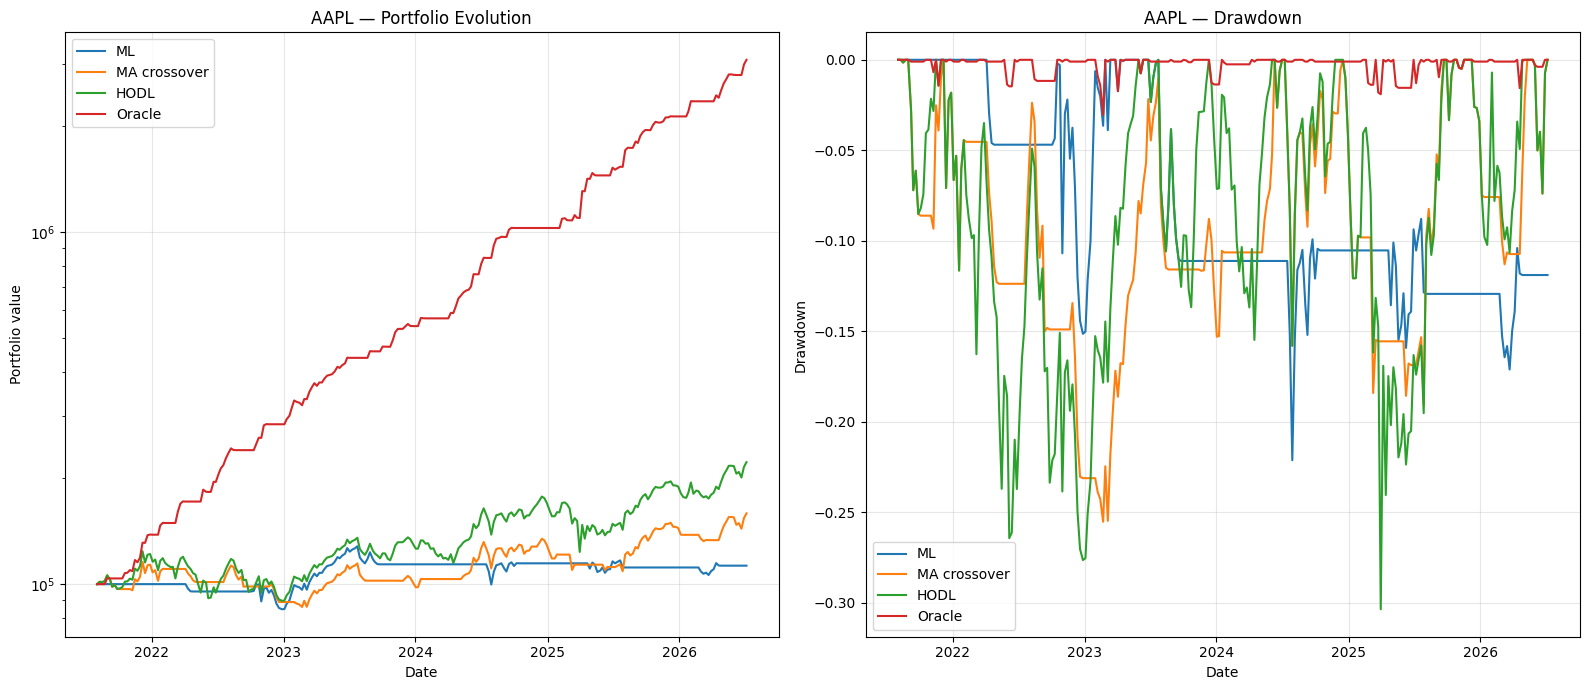

In [15]:
# ==========================================================
# BENCHMARK VISUALIZATION
# ==========================================================

PLOT_ANNUAL_RETURNS = False
USE_LOG_SCALE = True


# ----------------------------------------------------------
# Collect deterministic strategy results
# ----------------------------------------------------------

strategy_backtests = {
    "ML": bt_ml,
    "MA crossover": bt_q1,
    "HODL": bt_hodl,
    "Oracle": bt_oracle,
}


# ----------------------------------------------------------
# Equity and drawdown data
# ----------------------------------------------------------

equity_curves = pd.DataFrame({
    name: backtest["equity"]
    for name, backtest in strategy_backtests.items()
})

drawdown_curves = pd.DataFrame({
    name: backtest["drawdown"]
    for name, backtest in strategy_backtests.items()
})


# ----------------------------------------------------------
# Plot layout
# ----------------------------------------------------------

if PLOT_ANNUAL_RETURNS:

    figure, axes = plt.subplots(
        nrows=1,
        ncols=3,
        figsize=(20, 7),
    )

    equity_axis = axes[0]
    drawdown_axis = axes[1]
    annual_axis = axes[2]

else:

    figure, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(16, 7),
    )

    equity_axis = axes[0]
    drawdown_axis = axes[1]


# ----------------------------------------------------------
# Equity curves
# ----------------------------------------------------------

for strategy_name in equity_curves.columns:

    equity_axis.plot(
        equity_curves.index,
        equity_curves[strategy_name],
        label=strategy_name,
    )

equity_axis.set_title(
    f"{ticker} — Portfolio Evolution"
)

equity_axis.set_xlabel("Date")
equity_axis.set_ylabel("Portfolio value")

if USE_LOG_SCALE:
    equity_axis.set_yscale("log")

equity_axis.legend()
equity_axis.grid(
    alpha=0.3
)


# ----------------------------------------------------------
# Drawdown curves
# ----------------------------------------------------------

for strategy_name in drawdown_curves.columns:

    drawdown_axis.plot(
        drawdown_curves.index,
        drawdown_curves[strategy_name],
        label=strategy_name,
    )

drawdown_axis.set_title(
    f"{ticker} — Drawdown"
)

drawdown_axis.set_xlabel("Date")
drawdown_axis.set_ylabel("Drawdown")

drawdown_axis.legend()
drawdown_axis.grid(
    alpha=0.3
)


# ----------------------------------------------------------
# Optional annual returns
# ----------------------------------------------------------

if PLOT_ANNUAL_RETURNS:

    annual_returns = pd.DataFrame({
        strategy_name: (
            backtest["equity"]
            .resample("YE")
            .last()
            .pct_change()
        )
        for strategy_name, backtest
        in strategy_backtests.items()
    })

    annual_returns.index = (
        annual_returns.index.year
    )

    annual_returns.plot(
        kind="bar",
        ax=annual_axis,
    )

    annual_axis.axhline(
        0,
        linewidth=1,
        linestyle="--",
    )

    annual_axis.set_title(
        f"{ticker} — Annual Returns"
    )

    annual_axis.set_xlabel("Year")
    annual_axis.set_ylabel("Return")

    annual_axis.legend()


plt.tight_layout()
plt.show()